In [1]:

# why multi-head is better than single-head ? 

# https://gemini.google.com/app/8720e969a2fcbae5
# The Averaging Bottleneck (Single Head)
# Representation Subspaces (Multi-Head)
# The Computational Equivalence

# too many heads:
#   Dot-product discriminability collapses: In a d_head-dimensional random projection, the variance of the dot product between two vectors scales with d_head, When d_head gets very small, there just isn't enough room for queries/keys to be pushed far apart in angle — random or near-random keys start looking similar to a query, so the softmax degenerates toward uniform, You get noise-induced averaging, which is the same symptom you were trying to escape (uniform attention), just caused by insufficient dimensionality instead of a forced single softmax.
#   Johnson–Lindenstrauss-style capacity limit. To keep pairwise angular relationships between N distinguishable concepts roughly preserved under a linear projection, you need roughly d_head = O(log N / ε²) dimensions. Below that, key vectors for genuinely different tokens start colliding in the projected space — the head physically cannot keep enough patterns separable   


# pay-off curve = inverted-U
# 
# performance
    # ^
    # |         ____________
    # |       /              \___
    # |      /                    \___
    # |     /                          \
    # |    /
    # |   /
    # +--+---------------------------------> h (num heads, d_head = d_model/h)
    #    1    few heads    "sweet spot"    many tiny heads
    #    (averaging       (diverse, still  (noisy dot products,
    #     bottleneck)      well-powered)    redundant/collapsing heads)
#  


# Multi-head splitting trades a combinatorial bottleneck (can't represent multiple relations at once) for a dimensionality/statistical 
# bottleneck (each relation is represented too weakly to be reliably distinguished). The optimum sits where you've captured most of the 
# useful "different relation types need different heads" benefit before dot-product signal-to-noise per head starts degrading — empirically, 
# that's around d_head ≈ 64–128 for typical model/vocab scales, largely independent of total model size.


#---
# implement YaRN for positinal encodings, QK norm

# MHA: num_query_heads == num_kv_heads
# GQA: 1 < num_kv_heads < num_query_heads and num_query_heads % num_kv_heads == 0
# MQA: num_kv_heads == 1


# TODO:

# line-by-line explaination of this script, weight init method used, RoPE rewrite, compute graph vis, tensor health check, attentino map vis
# make a report on: SHA/MQA/GQA/MHA performance/cost 
# reposr benchmark: cached vs. uncached decode latency as sequence length grows

Give an efficient pytorch implementation for grouped query attention with RoPE and kv caching, in 3 python classes, sub_block, block and model. Use einops to clarify every tensor operation, use a dedicated KV cache data class, give clear and explicit names to tensors and their dimensions and write out their operation in einops strings step-by-step. for efficiency precompute RoPE, but know that during inference it is possible to generate beyond the pre-set max_seq_len yet only using the last context_window length number of tokens for next token prediction, while the KV cache which is also statically pre-allocated will only keep the last max_seq_len number of tokens, let the cache object do the management so the attention module stays cleaner. I will use torch.nn.functional.scaled_dot_product_attention with isCausal=True, 

---



In [2]:
import time
# ! will NEED PyTorch version 2.5+ --> for SDPA(enable_gqa=True)
import torch
import torch.nn as nn
from typing import Union
import torch.nn.functional as F
from dataclasses import dataclass
from typing import Optional, Tuple
from einops import rearrange, einsum

from model_config import ModelConfig
import training_engine as training_engine 
from utils import init_custom_weight, inspect_tensor
from inference_engine import advanced_inference, KV_cache




# Device configuration
device = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"Device:         {device}")
print(f"PyTorch:        {torch.__version__}")

if torch.cuda.is_available():
    print(f"GPU:            {torch.cuda.get_device_name(0)}")
    print(f"CUDA version:   {torch.version.cuda}")

Device:         cuda
PyTorch:        2.8.0+cu129
GPU:            NVIDIA GeForce GTX 1660 Ti
CUDA version:   12.9


In [3]:

configs = ModelConfig(

    model_name="level2_attention_models",
    tied_embeddings=False,  
    
    embed_dim=2**5,   # 32
    vocab_size=2**11,  # 2048
    num_layers=5,
    max_context_window=2**6,   # 64
    
    num_q_heads=2**0,  # 1 | 1   x   x    x
    num_kv_heads=2**0, # 1 | 1   1   2+   x
    
    max_training_batch_size=2**4,   # 16
    learning_rate=1e-3,

    rope_theta=10000.0, 

    mlp_to_embed_expand_factor= None,
    num_experts= None,
    num_experts_per_tkn=None,
   
    save_path="../models/level3_attention_models.pt",
    loss_history="../models/level3_attention_models_loss_history.txt"
)



print(configs)

ModelConfig(model_name='level2_attention_models', tied_embeddings=False, embed_dim=32, vocab_size=2048, num_layers=5, max_context_window=64, num_q_heads=1, num_kv_heads=1, max_training_batch_size=16, learning_rate=0.001, rope_theta=10000.0, mlp_to_embed_expand_factor=None, num_experts=None, num_experts_per_tkn=None, save_path='../models/level3_attention_models.pt', loss_history='../models/level3_attention_models_loss_history.txt')


In [4]:
class RotaryEmbedding(nn.Module):

    def __init__(self, config:ModelConfig):
        super().__init__()

        base     = config.rope_theta
        head_dim = config.embed_dim // config.num_q_heads

        # shape: [head_dim // 2]
        inv_freq = 1.0 / (
            base ** (torch.arange(0, head_dim, 2).float() / head_dim)
        )
        self.register_buffer("inv_freq", inv_freq, persistent=False)


    def forward(
            self,
            position_ids: torch.Tensor,   # [B, seq] or [seq]
            dtype= torch.float32,
        ) -> tuple[torch.Tensor, torch.Tensor]:
            """position_ids: [B, T] (or [T]) -> cos, sin of shape [B, 1, T, head_dim]"""

            if position_ids.dim() == 1:
                position_ids = position_ids.unsqueeze(0)          # [1, seq]


            # position_ids: [B, seq]  (integer)
            # inv_freq:     [head_dim//2]
            # freqs:        [B, seq, head_dim//2]
            freqs = torch.einsum(
                "bi,j->bij",
                position_ids.to(dtype=self.inv_freq.dtype),
                self.inv_freq,
            )

            emb = torch.cat((freqs, freqs), dim=-1) # [B, seq, head_dim]

            # broadcast over the head dimension → [B, 1, seq, head_dim]
            return emb.cos().to(dtype).unsqueeze(1), emb.sin().to(dtype).unsqueeze(1)

    # def _build_cache(self, seq_len: int):
    #     t = torch.arange(seq_len, device=device, dtype=self.inv_freq.dtype)
    #     freqs = torch.outer(t, self.inv_freq)
    #     emb = torch.cat((freqs, freqs), dim=-1)
    #     self.register_buffer("cos_cached", emb.cos(), persistent=False)
    #     self.register_buffer("sin_cached", emb.sin(), persistent=False)
    #     self.max_seq_len = seq_len



def rotate_half(x: torch.Tensor) -> torch.Tensor:
    x1, x2 = x.chunk(2, dim=-1)
    return torch.cat((-x2, x1), dim=-1)


def apply_rotary_pos_emb(
    q:   torch.Tensor,
    k:   torch.Tensor,
    cos: torch.Tensor,
    sin: torch.Tensor,
) -> Tuple[torch.Tensor, torch.Tensor]:
    
    cos = cos.to(device=q.device, dtype=q.dtype)
    sin = sin.to(device=q.device, dtype=q.dtype)

    q = (q * cos) + (rotate_half(q) * sin)
    k = (k * cos) + (rotate_half(k) * sin)
    return q, k

In [5]:
class Attention_SubBlock(nn.Module):

    def __init__(self, config:ModelConfig):
        super().__init__()

        self.embed_dim    = config.embed_dim
        self.num_q_heads  = config.num_q_heads
        self.num_kv_heads = config.num_kv_heads
        self.num_layers   = config.num_layers
        
        if self.embed_dim % self.num_q_heads != 0:
            raise ValueError("embed_dim must be divisible by num_q_heads")
        if self.num_q_heads % self.num_kv_heads != 0:
            raise ValueError("num_q_heads must be divisible by num_kv_heads")

        self.head_dim = self.embed_dim // self.num_q_heads
        self.q_dim    = self.num_q_heads * self.head_dim
        self.kv_dim   = self.num_kv_heads * self.head_dim

        # self.W_q = nn.Parameter(torch.empty(self.embed_dim, self.num_q_heads  * self.head_dim))
        # self.W_k = nn.Parameter(torch.empty(self.embed_dim, self.num_kv_heads * self.head_dim))
        # self.W_v = nn.Parameter(torch.empty(self.embed_dim, self.num_kv_heads * self.head_dim))
        
        # ONE matrix for Q, K and V: columns are [ q | k | v ]
        self.W_qkv = nn.Parameter(torch.empty(self.embed_dim, self.q_dim + 2 * self.kv_dim))
        self.W_o = nn.Parameter(torch.empty(self.q_dim, self.embed_dim))

        self.init_params()


    def init_params(self):

        q_end = self.q_dim
        k_end = q_end + self.kv_dim

        W_q = self.W_qkv[:, :q_end]
        W_k = self.W_qkv[:, q_end:k_end]
        W_v = self.W_qkv[:, k_end:]

        init_custom_weight(W_q, is_residual_output=False)
        init_custom_weight(W_k, is_residual_output=False)
        init_custom_weight(W_v, is_residual_output=False)

        # Residual output projection (scaled by depth)
        init_custom_weight(self.W_o, 
                           is_residual_output=True, 
                           num_layers=self.num_layers)



    def forward(
        self,
        x: torch.Tensor,
        cos: torch.Tensor,          # [B, 1, seq, head_dim] – already computed
        sin: torch.Tensor,
        cache: Optional[KV_cache] = None,
        layer_idx: int = 0,
        
        slot_ids: Optional[torch.Tensor] = None,
        attn_mask: Optional[torch.Tensor] = None,   # [B, 1, T, kv_len] bool, from cache.prepare()
    ) -> torch.Tensor:

        batch_size, seq_len, embed_dim = x.shape

        qkv = x @ self.W_qkv  # [B, T, q_dim + 2*kv_dim]
        q, k, v = qkv.split([self.q_dim, self.kv_dim, self.kv_dim], dim=-1)


        # q = rearrange(q, "b t (h d) -> b h t d", h=self.num_q_heads)
        # k = rearrange(k, "b t (h d) -> b h t d", h=self.num_kv_heads)
        # v = rearrange(v, "b t (h d) -> b h t d", h=self.num_kv_heads)

        q = rearrange(q, 
                      "batch_size seq_len (num_q_heads head_dim)" 
                      " -> " 
                      "batch_size num_q_heads seq_len head_dim", 
                      num_q_heads=self.num_q_heads)
        
        k = rearrange(k, 
                      "batch_size seq_len (num_kv_heads head_dim)" 
                      " -> " 
                      "batch_size num_kv_heads seq_len head_dim",
                      num_kv_heads=self.num_kv_heads)
        
        v = rearrange(v, 
                      "batch_size seq_len (num_kv_heads head_dim)" 
                      " -> " 
                      "batch_size num_kv_heads seq_len head_dim",
                      num_kv_heads=self.num_kv_heads)


        q, k = apply_rotary_pos_emb(q, k, cos, sin)


        use_gqa = self.num_q_heads != self.num_kv_heads


        # ---------- under construction ---------------
        if cache is not None:
            k, v = cache.update(layer_idx, k, v)


        out = F.scaled_dot_product_attention(
            q, k, v,
            is_causal=(q.shape[2] == k.shape[2]),
            enable_gqa=(self.num_q_heads != self.num_kv_heads),
        )
        # ---------- under construction ---------------


        # Merge attention heads
        out = rearrange(
            out,
            "batch_size num_q_heads seq_len head_dim"
            " -> " 
            "batch_size seq_len (num_q_heads head_dim)",
        )


        return out @ self.W_o


In [6]:
class Transformer_Block(nn.Module):
    def __init__(self, config:ModelConfig):
        super().__init__()
        self.attention_sub_block = Attention_SubBlock(config)
        self.norm = nn.RMSNorm(config.embed_dim)


    def forward(
        self,
        x: torch.Tensor,
        cos: torch.Tensor,
        sin: torch.Tensor,
        cache: Optional[KV_cache] = None,
        layer_idx: int = 0,

        slot_ids=None, 
        attn_mask=None

    ) -> torch.Tensor:
        
        residual = x

        x = self.norm(x)
        x = self.attention_sub_block(x, 
                                     cos, 
                                     sin, 
                                     cache=cache, 
                                     layer_idx=layer_idx,
                                     slot_ids=slot_ids, 
                                     attn_mask=attn_mask,
                                    )
        
        return  x + residual


In [7]:
class Level2_Model(nn.Module):

    def __init__(self, config:ModelConfig=configs):
        super().__init__()

        self.vocab_size = config.vocab_size
        self.embed_dim  = config.embed_dim  

        self.tied_embeddings = configs.tied_embeddings      


        self.embed  = nn.Parameter(torch.empty(self.vocab_size, self.embed_dim))
        
        if not self.tied_embeddings:
            self.unembed = nn.Parameter(torch.empty(self.embed_dim, self.vocab_size))


        self.rotary = RotaryEmbedding(config)

        self.layers = nn.ModuleList([Transformer_Block(config) 
                                     for _ in range(config.num_layers)
                                    ])

        self.final_rms_norm = nn.RMSNorm(config.embed_dim)

        # self.unembed = nn.Parameter(torch.empty(self.embed_dim, self.vocab_size))

        self.init_params()



    def init_params(self):
        init_custom_weight(self.embed,   is_residual_output=False)
        
        if not self.tied_embeddings:
            init_custom_weight(self.unembed, is_residual_output=False)


    def forward(
            self, 
            input_ids: torch.tensor, 
            cache: Optional[KV_cache] = None,
            position_ids: Optional[torch.Tensor] = None,

            slot_ids: Optional[torch.Tensor] = None,       # which cache slot each batch row uses

    ) -> torch.Tensor:

        batch_size, seq_len = input_ids.shape

        # device = input_ids.device
        # print('input_ids.device -> ', input_ids.device)

        # [batch_size, seq_len] -> [batch_size, seq_len, embed_dim]
        x = self.embed[input_ids] 


        attn_mask = None

        if position_ids is None:
            if cache is not None and cache.current_abs_pos > 0:
                start = cache.current_abs_pos
                position_ids = torch.arange(
                    start, start + seq_len, device=device, dtype=torch.long
                )
            else:
                position_ids = torch.arange(
                    seq_len, device=device, dtype=torch.long
                )
        else:
            # caller-supplied ids must also be on the right device
            position_ids = position_ids.to(device=device, dtype=torch.long)

        if position_ids.dim() == 1:
            position_ids = position_ids.unsqueeze(0).expand(batch_size, -1)


        cos, sin = self.rotary(position_ids, dtype=x.dtype)


        
        for i, layer in enumerate(self.layers):
                x = layer(x, 
                          cos, 
                          sin, 
                          cache=cache, 
                          layer_idx=i,
                          slot_ids=slot_ids,
                          attn_mask=attn_mask,
                        )        


        # ------------- UNDER CONSTRUCTION ----------------------
        # if cache is not None:
        #     cache.commit(slot_ids, seq_len)            # advance lengths once, after ALL layers
        # ------------- UNDER CONSTRUCTION ----------------------


        x = self.final_rms_norm(x)


        if self.tied_embeddings:
            return x @ self.embed.T                    # [B, T, V]
        return x @ self.unembed

        
        # logits = einsum(x, self.unembed, 
        #                 "batch_size seq_len embed_dim, " 
        #                 "embed_dim vocab_size"
        #                 " -> "
        #                 "batch_size seq_len vocab_size")

        # return logits

    

Step 0000 | Batch Loss: 7.6302 nats
Step 0005 | Batch Loss: 7.6145 nats
Step 0010 | Batch Loss: 7.5681 nats
Step 0015 | Batch Loss: 7.5374 nats
Step 0020 | Batch Loss: 7.4706 nats
Step 0025 | Batch Loss: 7.4267 nats
Step 0030 | Batch Loss: 7.3463 nats
Step 0035 | Batch Loss: 7.3109 nats
Step 0040 | Batch Loss: 7.2824 nats
Step 0045 | Batch Loss: 7.2175 nats
Step 0050 | Batch Loss: 7.1830 nats
Step 0055 | Batch Loss: 7.1485 nats
Step 0060 | Batch Loss: 7.1574 nats
Step 0065 | Batch Loss: 7.1330 nats
Step 0070 | Batch Loss: 7.0615 nats
Step 0075 | Batch Loss: 7.0645 nats
Step 0080 | Batch Loss: 7.0763 nats
Step 0085 | Batch Loss: 7.0296 nats
Step 0090 | Batch Loss: 7.0392 nats
Step 0095 | Batch Loss: 6.9972 nats
Step 0099 | Batch Loss: 7.0460 nats

Saving model weights to: ../models/level3_attention_models.pt
Loss history successfully saved to ../models/level3_attention_models_loss_history.txt
Loaded 100 steps from ../models/level3_attention_models_loss_history.txt


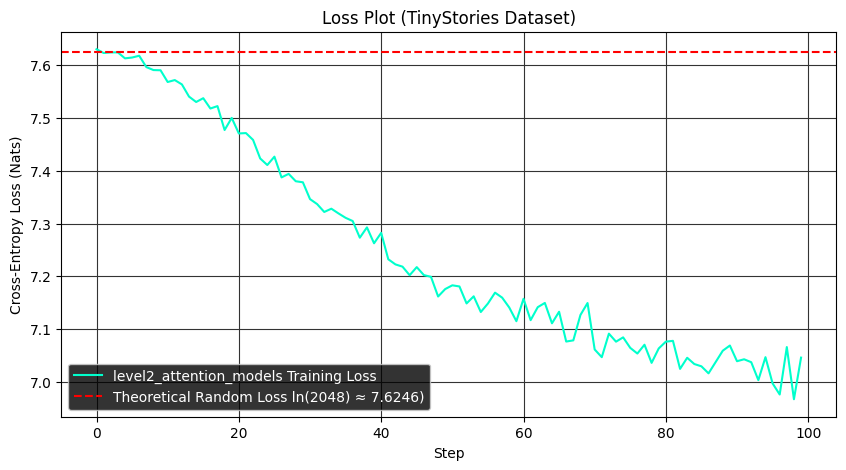

Loaded state_dict from ..\models\level3_attention_models.pt
Number of parameter tensors: 18
Number of parameters: 151,744

PARAMETER SUMMARY
embed: shape=(2048, 32), dtype=torch.float32, requires_grad=False, numel=65,536
unembed: shape=(32, 2048), dtype=torch.float32, requires_grad=False, numel=65,536
layers.0.attention_sub_block.W_qkv: shape=(32, 96), dtype=torch.float32, requires_grad=False, numel=3,072
layers.0.attention_sub_block.W_o: shape=(32, 32), dtype=torch.float32, requires_grad=False, numel=1,024
layers.0.norm.weight: shape=(32,), dtype=torch.float32, requires_grad=False, numel=32
layers.1.attention_sub_block.W_qkv: shape=(32, 96), dtype=torch.float32, requires_grad=False, numel=3,072
layers.1.attention_sub_block.W_o: shape=(32, 32), dtype=torch.float32, requires_grad=False, numel=1,024
layers.1.norm.weight: shape=(32,), dtype=torch.float32, requires_grad=False, numel=32
layers.2.attention_sub_block.W_qkv: shape=(32, 96), dtype=torch.float32, requires_grad=False, numel=3,072

In [8]:


model = Level2_Model()


if torch.cuda.is_available():
    torch.cuda.synchronize()
start = time.time()


training_engine.train_and_save_model(model, configs, device, 100)

training_engine.plot_loss_history(configs)

training_engine.inspect_weight_file(configs.save_path)


if torch.cuda.is_available():
    torch.cuda.synchronize()
total_time = time.time() - start
print("total_time -> ", total_time)



if torch.cuda.is_available():
    max_mem_bytes = torch.cuda.max_memory_allocated()
    max_mem_gb = max_mem_bytes / (1024 ** 3)
    print(f"Max memory allocated: {max_mem_gb:.2f} GB")


In [9]:
eos_id = 83 #TODO: no hardcoding 

# use "continuous batching" to pack same-length prompts together 
prompt_strs = [
    "write a story about",
    "write like a little boy that was angry",
    "write as a little boy that was happy,",
] # 3 prompts each w/ len of 8.


result = advanced_inference(model,
                            configs, 
                            max_num_gen_steps=33, 
                            prompt_strs=prompt_strs, 
                            device=device,
                            eos_token_id=eos_id
                            ) # [batch_size, prompt_len + num_get_steps]

for prmpt in result:
    print("---"*80)
    print(prmpt)


[INFO] Loaded weights from ..\models\level3_attention_models.pt (151,744 parameters)
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
swith t and m. He . She . They , . it itsay bs . They . They his ps  and sto the ta p. He mt.

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
tthey itp. He st. The ! a<|endoftext|>y sem. He said in the sedsitsyy it sw. He edeed in the a ing
-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------